In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Casper\OneDrive\Masaüstü\netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
print(df.shape)
print(df.isnull().sum())

(8807, 12)
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [7]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df = df.dropna(subset=['date_added', 'rating', 'duration'])

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


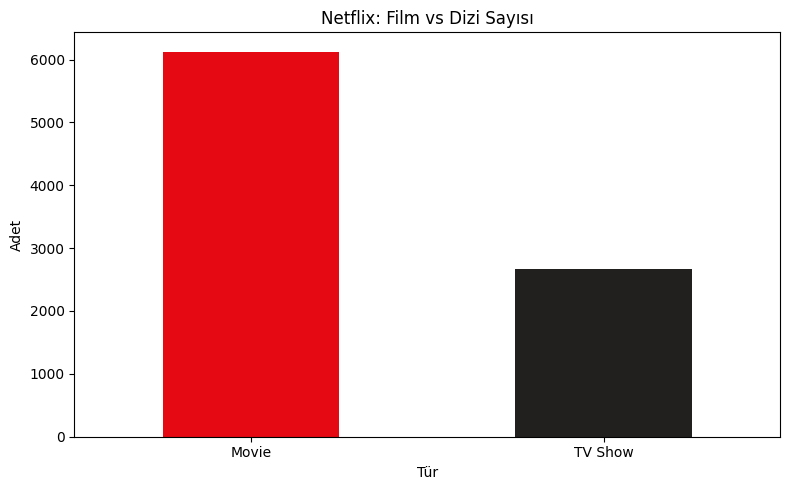

In [8]:
plt.figure(figsize=(8,5))
df['type'].value_counts().plot(kind='bar', color=['#E50914', '#221F1F'])
plt.title('Netflix: Film vs Dizi Sayısı')
plt.xlabel('Tür')
plt.ylabel('Adet')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

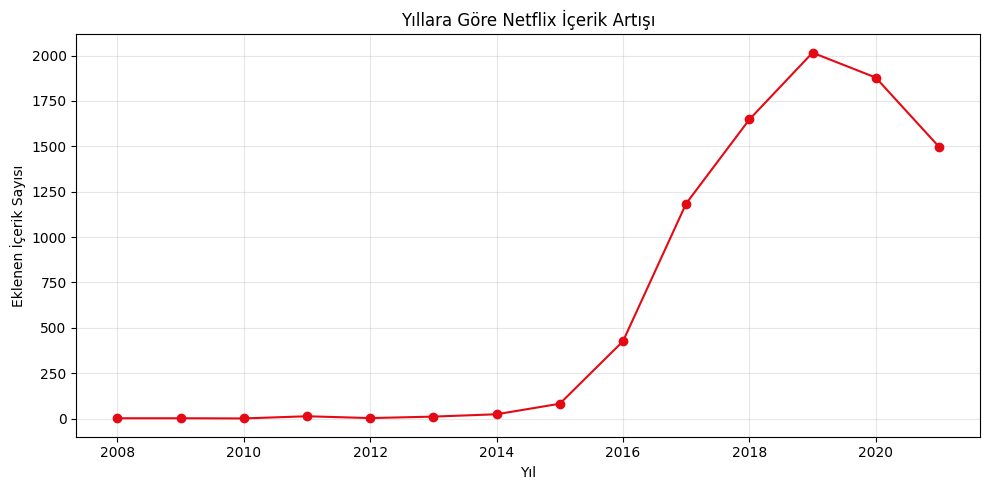

In [12]:
df['year_added'] = pd.to_datetime(df['date_added'], format='mixed').dt.year

plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='#E50914')
plt.title('Yıllara Göre Netflix İçerik Artışı')
plt.xlabel('Yıl')
plt.ylabel('Eklenen İçerik Sayısı')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

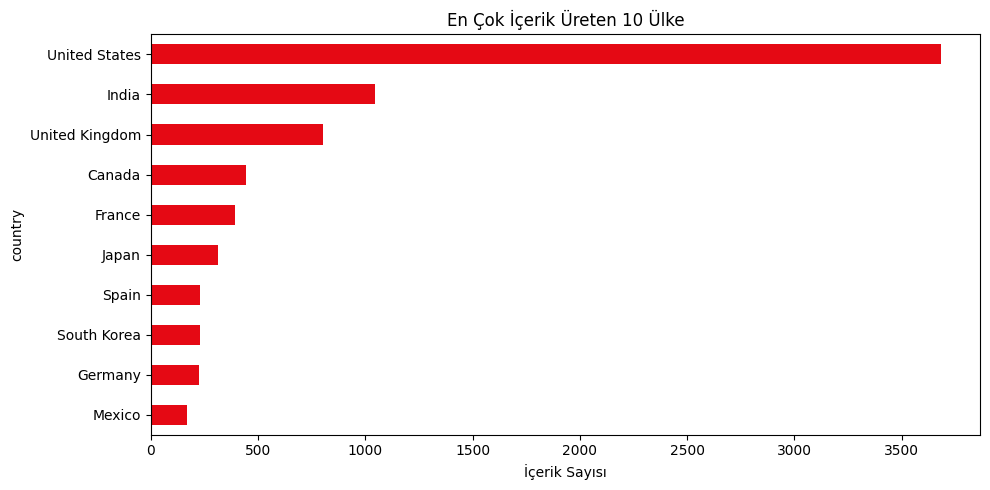

In [13]:
plt.figure(figsize=(10,5))
df[df['country'] != 'Unknown']['country'].str.split(',').explode().str.strip().value_counts().head(10).plot(kind='barh', color='#E50914')
plt.title('En Çok İçerik Üreten 10 Ülke')
plt.xlabel('İçerik Sayısı')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

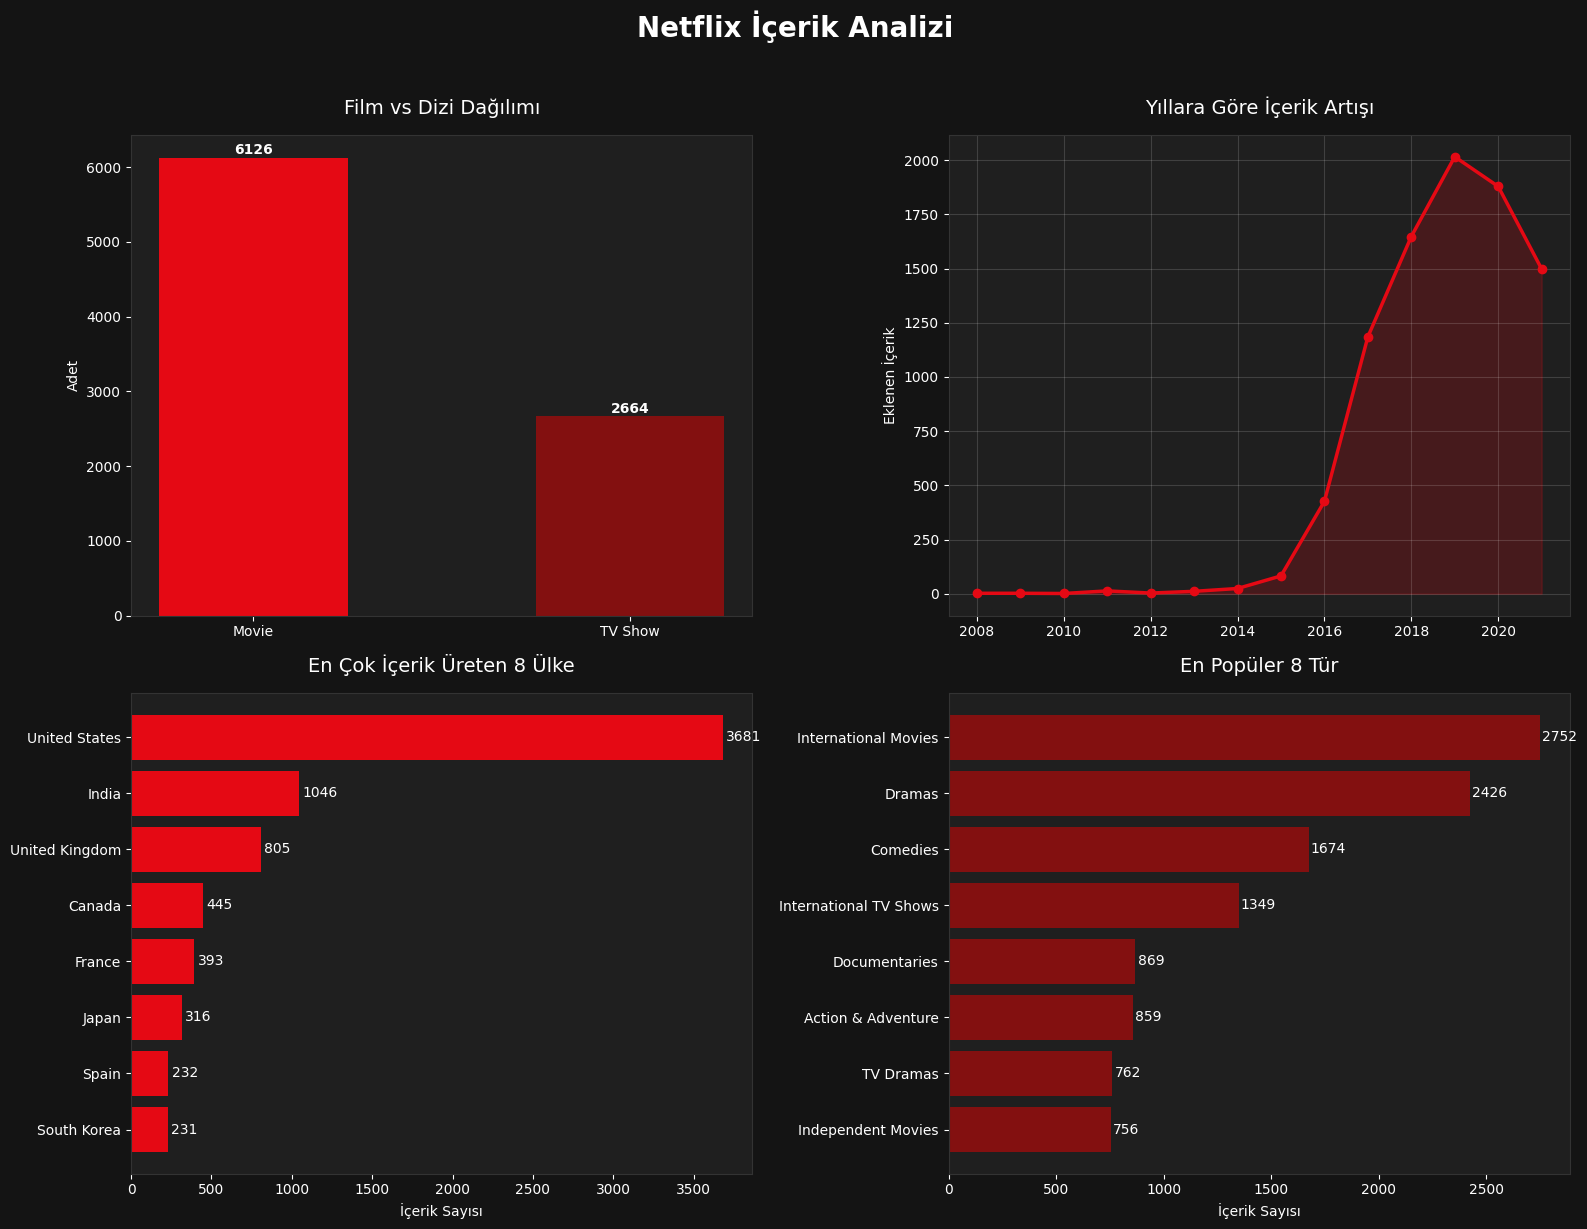

Dashboard kaydedildi!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#141414')

for ax in axes.flatten():
    ax.set_facecolor('#1f1f1f')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# 1. Film vs Dizi
type_counts = df['type'].value_counts()
axes[0,0].bar(type_counts.index, type_counts.values, color=['#E50914', '#831010'], width=0.5)
axes[0,0].set_title('Film vs Dizi Dağılımı', fontsize=14, pad=15)
axes[0,0].set_ylabel('Adet')
for i, v in enumerate(type_counts.values):
    axes[0,0].text(i, v + 50, str(v), ha='center', color='white', fontweight='bold')

# 2. Yıllara göre artış
yearly = df['year_added'].value_counts().sort_index()
axes[0,1].plot(yearly.index, yearly.values, color='#E50914', marker='o', linewidth=2.5, markersize=6)
axes[0,1].fill_between(yearly.index, yearly.values, alpha=0.2, color='#E50914')
axes[0,1].set_title('Yıllara Göre İçerik Artışı', fontsize=14, pad=15)
axes[0,1].set_ylabel('Eklenen İçerik')
axes[0,1].grid(True, alpha=0.15, color='white')

# 3. En çok içerik üreten ülkeler
countries = df[df['country'] != 'Unknown']['country'].str.split(',').explode().str.strip().value_counts().head(8)
bars = axes[1,0].barh(countries.index, countries.values, color='#E50914')
axes[1,0].set_title('En Çok İçerik Üreten 8 Ülke', fontsize=14, pad=15)
axes[1,0].set_xlabel('İçerik Sayısı')
axes[1,0].invert_yaxis()
for bar, val in zip(bars, countries.values):
    axes[1,0].text(val + 20, bar.get_y() + bar.get_height()/2, str(val), va='center', color='white')

# 4. En popüler türler
genres = df['listed_in'].str.split(',').explode().str.strip().value_counts().head(8)
axes[1,1].barh(genres.index, genres.values, color='#831010')
axes[1,1].set_title('En Popüler 8 Tür', fontsize=14, pad=15)
axes[1,1].set_xlabel('İçerik Sayısı')
axes[1,1].invert_yaxis()
for i, val in enumerate(genres.values):
    axes[1,1].text(val + 10, i, str(val), va='center', color='white')

fig.suptitle('Netflix İçerik Analizi', fontsize=20, color='white', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('netflix_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#141414')
plt.show()
print("Dashboard kaydedildi!")

In [15]:
pip install scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 808.1 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.1 MB 1.0 MB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.1 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.1 MB 1.2 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.0 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 1.0 MB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.1 MB 1.1 MB/s eta 0:00:06
   ----------- ---------------------------- 2.4/8.1 MB 1.1 MB/s eta 0:00:06
   ------------ ----------------------


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Özellikler hazırla
df['release_year'] = df['release_year'].astype(int)
df['country_encoded'] = LabelEncoder().fit_transform(df['country'])
df['rating_encoded'] = LabelEncoder().fit_transform(df['rating'])

X = df[['release_year', 'country_encoded', 'rating_encoded']]
y = (df['type'] == 'Movie').astype(int)

# Eğit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Sonuç
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: %{acc*100:.1f}")
print("\n", classification_report(y_test, y_pred, target_names=['TV Show', 'Movie']))

Model Doğruluğu: %73.6

               precision    recall  f1-score   support

     TV Show       0.57      0.50      0.53       531
       Movie       0.79      0.84      0.82      1227

    accuracy                           0.74      1758
   macro avg       0.68      0.67      0.67      1758
weighted avg       0.73      0.74      0.73      1758

